# Primer Examen del Módulo 3
## Planteamiento del problema


## Preparación del entorno
### Carga de Módulos



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

from datetime import datetime
from sklearn import set_config
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA

### Configuración Inicial

In [3]:
random_seed = 333  # Semilla para reproducibilidad de resultados
np.random.seed(random_seed)  # Para reproducibilidad

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 15)



set_config(transform_output="pandas")
set_config(display='diagram')

warnings.filterwarnings("ignore")
%matplotlib inline

print("Entorno configurado correctamente.")
print("Semilla usada:", random_seed)

Entorno configurado correctamente.
Semilla usada: 333


## Carga del conjunto de datos



In [4]:
path = "/content/drive/MyDrive/Diplomado/Modulo_3/Examen_2/Codes/"
df = pd.read_csv(path + "FIFA19-DS.csv", encoding='utf-8-sig', low_memory=False)
df.head()

,ID,Age,Overall,Potential,Value,Wage,Special,International Reputation,Weak Foot,Skill Moves,Work Rate,Height,Weight,LS,ST,RS,LW,LF,CF,RF,RW,LAM,CAM,RAM,LM,LCM,CM,RCM,RM,LWB,LDM,CDM,RDM,RWB,LB,LCB,CB,RCB,RB,Crossing,Finishing,HeadingAccuracy,ShortPassing,Volleys,Dribbling,Curve,FKAccuracy,LongPassing,BallControl,Acceleration,SprintSpeed,Agility,Reactions,Balance,ShotPower,Jumping,Stamina,Strength,LongShots,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Preferred Foot,Body Type,Position
0,158023,31,94,94,110500000,565000,2202,5,4,4,4,5.70,159,90.0,90.0,90.0,94.0,95.0,95.0,95.0,94.0,95.0,95.0,95.0,93.0,86.0,86.0,86.0,93.0,66.0,63.0,63.0,63.0,66.0,61.0,49.0,49.0,49.0,61.0,84,95,70,90,86,97,93,94,87,96,91,86,91,95,95,85,68,72,59,94,48,22,94,94,75,96,33,28,26,6,11,15,14,8,Left,Lean,ST
1,20801,33,94,94,77000000,405000,2228,5,4,5,6,6.20,183,94.0,94.0,94.0,92.0,93.0,93.0,93.0,92.0,91.0,91.0,91.0,91.0,84.0,84.0,84.0,91.0,68.0,64.0,64.0,64.0,68.0,64.0,56.0,56.0,56.0,64.0,84,94,89,81,87,88,81,76,77,94,89,91,87,96,70,95,95,88,79,93,63,29,95,82,85,95,28,31,23,7,11,15,14,11,Right,Normal,ST
2,190871,26,92,93,118500000,290000,2143,5,5,5,7,5.90,150,87.0,87.0,87.0,92.0,92.0,92.0,92.0,92.0,92.0,92.0,92.0,91.0,84.0,84.0,84.0,91.0,68.0,63.0,63.0,63.0,68.0,63.0,50.0,50.0,50.0,63.0,79,87,62,84,84,96,88,87,78,95,94,90,96,94,84,80,61,81,49,82,56,36,89,87,81,94,27,24,33,9,9,15,15,11,Right,Lean,AM
3,192985,27,91,92,102000000,355000,2281,4,5,4,8,5.11,154,85.0,85.0,85.0,90.0,90.0,90.0,90.0,90.0,91.0,91.0,91.0,91.0,90.0,90.0,90.0,91.0,80.0,80.0,80.0,80.0,80.0,76.0,69.0,69.0,69.0,76.0,93,82,55,92,82,86,85,83,91,91,78,76,79,91,77,91,63,90,75,91,76,61,87,94,79,88,68,58,51,15,13,5,10,13,Right,Normal,MF
4,183277,27,91,91,93000000,340000,2142,4,4,4,7,5.80,163,86.0,86.0,86.0,92.0,91.0,91.0,91.0,92.0,92.0,92.0,92.0,92.0,85.0,85.0,85.0,92.0,69.0,66.0,66.0,66.0,69.0,63.0,52.0,52.0,52.0,63.0,81,84,61,89,80,95,83,79,83,94,94,88,95,90,94,82,56,83,66,80,54,41,87,89,86,91,34,27,22,11,12,6,8,8,Right,Normal,ST


In [5]:
df.shape

(17140, 76)

# EDA
## Análisis Exploratorio de Datos (EDA)


In [6]:
print("Tipos de datos:")
display(df.dtypes)

print("\nValores nulos por columna:")
display(df.isna().sum().sort_values(ascending=False))

print("\nResumen estadístico:")
display(df.describe().T)

Tipos de datos:


,0
ID,int64
Age,int64
Overall,int64
Potential,int64
Value,int64
...,...
GKPositioning,int64
GKReflexes,int64
Preferred Foot,object
Body Type,object



Valores nulos por columna:


,0
RAM,1842
CAM,1842
LAM,1842
LM,1842
RW,1842
...,...
GKPositioning,0
GKReflexes,0
Preferred Foot,0
Body Type,0



Resumen estadístico:


,count,mean,std,min,25%,50%,75%,max
ID,17140.0,2.140494e+05,3.001391e+04,16.0,199934.25,221602.0,236305.0,246620.0
Age,17140.0,2.515012e+01,4.658667e+00,16.0,21.00,25.0,28.0,44.0
Overall,17140.0,6.637194e+01,6.925482e+00,46.0,62.00,66.0,71.0,94.0
Potential,17140.0,7.138687e+01,6.159271e+00,48.0,67.00,71.0,75.0,95.0
Value,17140.0,2.486680e+06,5.731964e+06,0.0,325000.00,700000.0,2100000.0,118500000.0
...,...,...,...,...,...,...,...,...
GKDiving,17140.0,1.639924e+01,1.740806e+01,1.0,8.00,11.0,14.0,90.0
GKHandling,17140.0,1.617987e+01,1.664643e+01,1.0,8.00,11.0,14.0,92.0
GKKicking,17140.0,1.602993e+01,1.624687e+01,1.0,8.00,11.0,14.0,91.0
GKPositioning,17140.0,1.617345e+01,1.675260e+01,1.0,8.00,11.0,14.0,90.0


### Análsis Especifico de Posiciones
Este analisis es para la selección de variables

In [7]:
promedio_por_posicion = (
    df.groupby('Position')
      .mean(numeric_only=True)
)

print(promedio_por_posicion)

                     ID        Age    Overall  Potential         Value  \
Position                                                                 
AM        218816.673214  24.262500  67.087500  72.939881  3.413024e+06   
DF        213684.542081  25.510588  66.489774  71.040724  2.017768e+06   
DM        212014.846983  25.839080  67.477011  71.842672  2.493247e+06   
GK        208080.941911  25.953855  64.571661  69.859392  1.636317e+06   
MF        215877.626873  24.511534  66.300357  71.650416  2.848365e+06   
ST        214107.761619  25.048077  66.462340  71.536859  2.915697e+06   

                  Wage      Special  International Reputation  Weak Foot  \
Position                                                                   
AM        12326.785714  1704.413095                  1.139286   3.209524   
DF         9325.972851  1615.623348                  1.101176   2.832036   
DM        10415.229885  1756.035920                  1.125718   3.002155   
GK         6971.769815  104

De aquí se seleccionan las variables

Age, Agility, Crossing, Dribbling, Finishing, HeadingAccuracy, Height, Interceptions, LongPassing, Marking, ShortPassing, Skill Moves, SlidingTackle, StandingTackle, Vision, Volleys, Weight, Curve, FKAccuracy, LongShots




In [8]:
columnas = [
    'Age', 'Agility', 'Crossing', 'Dribbling', 'Finishing',
    'HeadingAccuracy', 'Height', 'Interceptions', 'LongPassing',
    'Marking', 'ShortPassing', 'Skill Moves', 'SlidingTackle',
    'StandingTackle', 'Vision', 'Volleys', 'Weight', 'Curve',
    'FKAccuracy', 'LongShots'
]

df = df[columnas]
df.shape

(17140, 20)

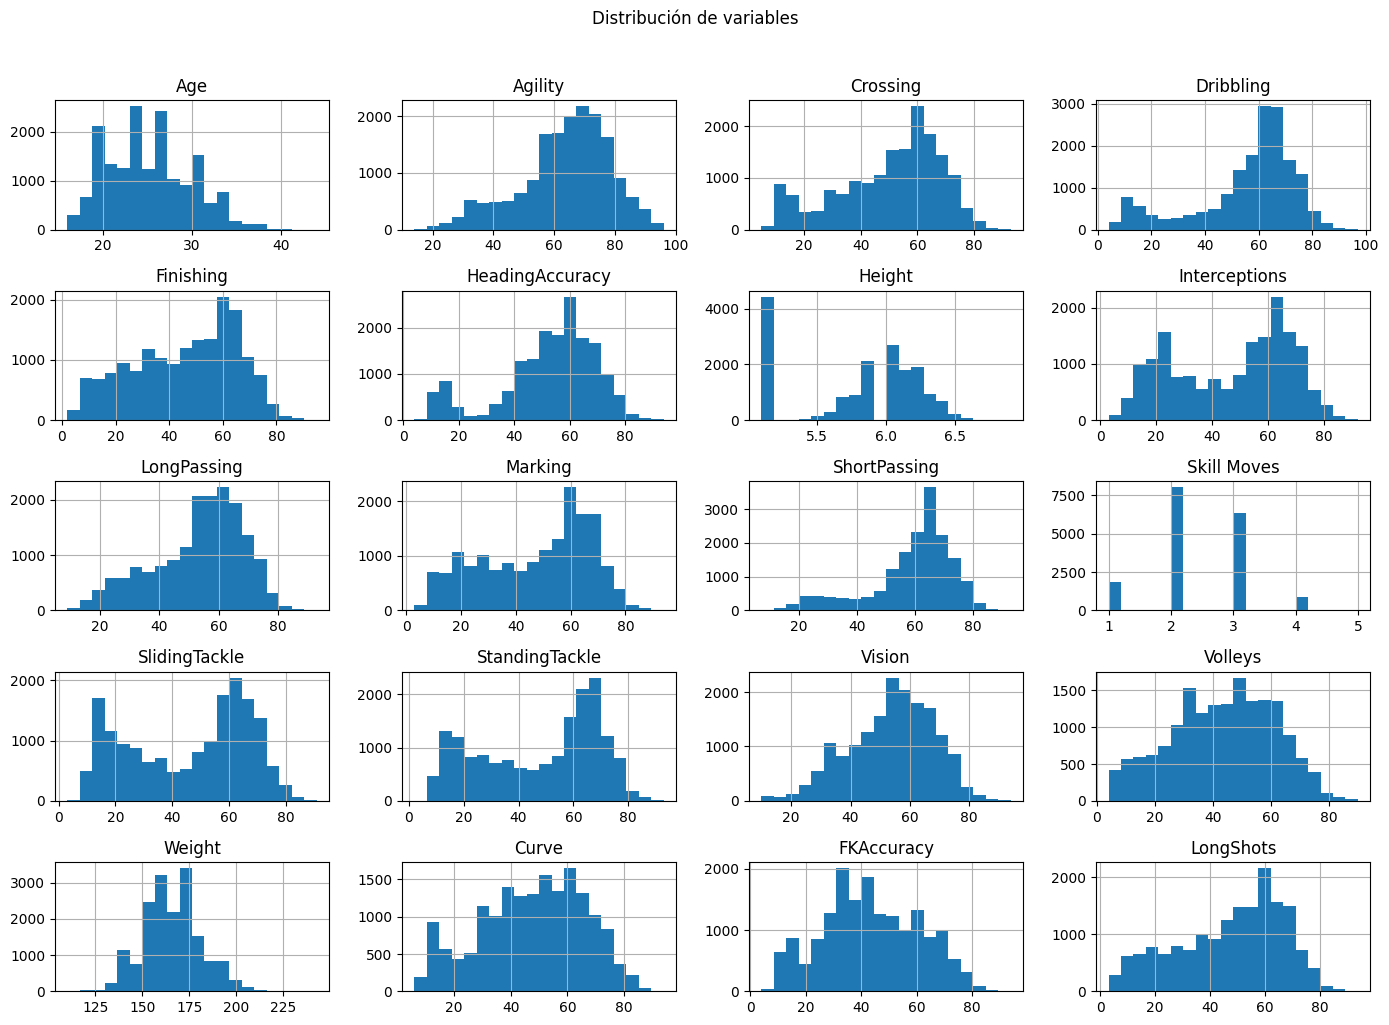

In [9]:
df.hist(bins=20, figsize=(14, 10))
plt.suptitle("Distribución de variables", y=1.02)
plt.tight_layout()
plt.show()

In [10]:
fig = px.histogram(
    df,
    x='Height',
    nbins=30,
    title='Histograma de Height'
)

fig.update_layout(
    xaxis_title='Height',
    yaxis_title='Frecuencia'
)

fig.show()

In [11]:
df_heatmap = df.copy()

# Matriz de correlación
corr = df_heatmap.corr(numeric_only=True)

# Heatmap
fig = px.imshow(
    corr,
    text_auto='.2f',
    aspect='auto',
    color_continuous_scale='RdBu_r',
    zmin=-1,
    zmax=1,
    title='Heatmap de correlación de todas las variables'
)

fig.update_layout(
    width=900,
    height=800
)

fig.show()

## Aplicación de PCA

In [12]:
pipe = make_pipeline(
        StandardScaler(),
        PCA())

pipe.fit(df)

Pipeline(steps=[('standardscaler', StandardScaler()), ('pca', PCA())])

In [13]:
pca = pipe.named_steps['pca']

ve = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(len(pca.explained_variance_ratio_))],
    'variance_ratio': pca.explained_variance_ratio_,
})


ve

,PC,variance_ratio
0,PC1,0.515373
1,PC2,0.191951
2,PC3,0.076580
3,PC4,0.046715
4,PC5,0.033191
...,...,...
15,PC16,0.004311
16,PC17,0.003673
17,PC18,0.003583
18,PC19,0.003104


In [14]:
# Varianza acumulada
ve['cumulative_variance'] = ve['variance_ratio'].cumsum()

In [15]:
# Número mínimo de componentes para explicar al menos 85%
n_componentes_85 = (ve['cumulative_variance'] < 0.88).sum() + 1

print(f'Número de componentes para alcanzar al menos 85%: {n_componentes_85}')

# Quedarse solo con esos componentes
ve_85 = ve.iloc[:n_componentes_85]
display(ve_85)

Número de componentes para alcanzar al menos 85%: 6


,PC,variance_ratio,cumulative_variance
0,PC1,0.515373,0.515373
1,PC2,0.191951,0.707323
2,PC3,0.076580,0.783903
3,PC4,0.046715,0.830618
4,PC5,0.033191,0.863809
5,PC6,0.024947,0.888757


In [16]:
explained_variance = 100 -np.cumsum(pca.explained_variance_ratio_ * 100)

pricipal_components = list(range(1, len(explained_variance) + 1))

trace = go.Scatter(x=pricipal_components, y=explained_variance, mode='lines+markers')
layout = go.Layout(title='Diagrama de Codo',
                     xaxis=dict(title='Número de Componentes Principales'),
                     yaxis=dict(title='Varianza Explicada (%)'),
                     hovermode='closest')

fig = go.Figure(data=[trace], layout=layout)
pio.show(fig)

In [17]:
componentes = pd.DataFrame(
    pca.components_[:n_componentes_85],
    columns=df.columns,
    index=[f'PC{i+1}' for i in range(n_componentes_85)]
)

display(componentes)

,Age,Agility,Crossing,Dribbling,Finishing,HeadingAccuracy,Height,Interceptions,LongPassing,Marking,ShortPassing,Skill Moves,SlidingTackle,StandingTackle,Vision,Volleys,Weight,Curve,FKAccuracy,LongShots
PC1,0.050720,0.229541,0.280715,0.289430,0.243419,0.192475,-0.116072,0.151858,0.266856,0.157211,0.288832,0.258293,0.138975,0.149055,0.245208,0.255042,-0.118562,0.279484,0.264815,0.272523
PC2,0.073915,-0.150806,-0.004198,-0.090793,-0.241123,0.184632,0.089074,0.423343,0.120079,0.406689,0.069545,-0.120976,0.438102,0.433671,-0.131118,-0.187943,0.124707,-0.101717,-0.077756,-0.142830
PC3,0.472116,-0.237926,-0.073687,-0.046837,0.144881,0.233967,0.451204,-0.038825,0.011189,-0.056057,0.028571,-0.011550,-0.111542,-0.084204,0.087231,0.177347,0.582354,0.043855,0.082183,0.146379
PC4,0.733252,0.024492,0.078502,-0.146175,-0.171843,-0.383540,-0.373976,0.057884,0.101051,-0.023720,-0.054176,-0.131455,-0.009907,-0.017135,0.186606,-0.105503,-0.111665,0.057013,0.137650,-0.048681
PC5,-0.162203,0.055783,0.083782,-0.028150,-0.181835,-0.497341,0.664609,0.021922,0.254096,-0.024510,0.074136,0.036013,0.016100,0.014980,0.313918,-0.155941,-0.119368,0.094882,0.131411,-0.065905
PC6,-0.408997,-0.360716,-0.031507,-0.059069,-0.058266,-0.217799,-0.430587,-0.006155,0.226930,-0.038410,0.089461,-0.049315,-0.002856,0.006264,0.285969,-0.051544,0.530772,0.068487,0.158821,0.048222


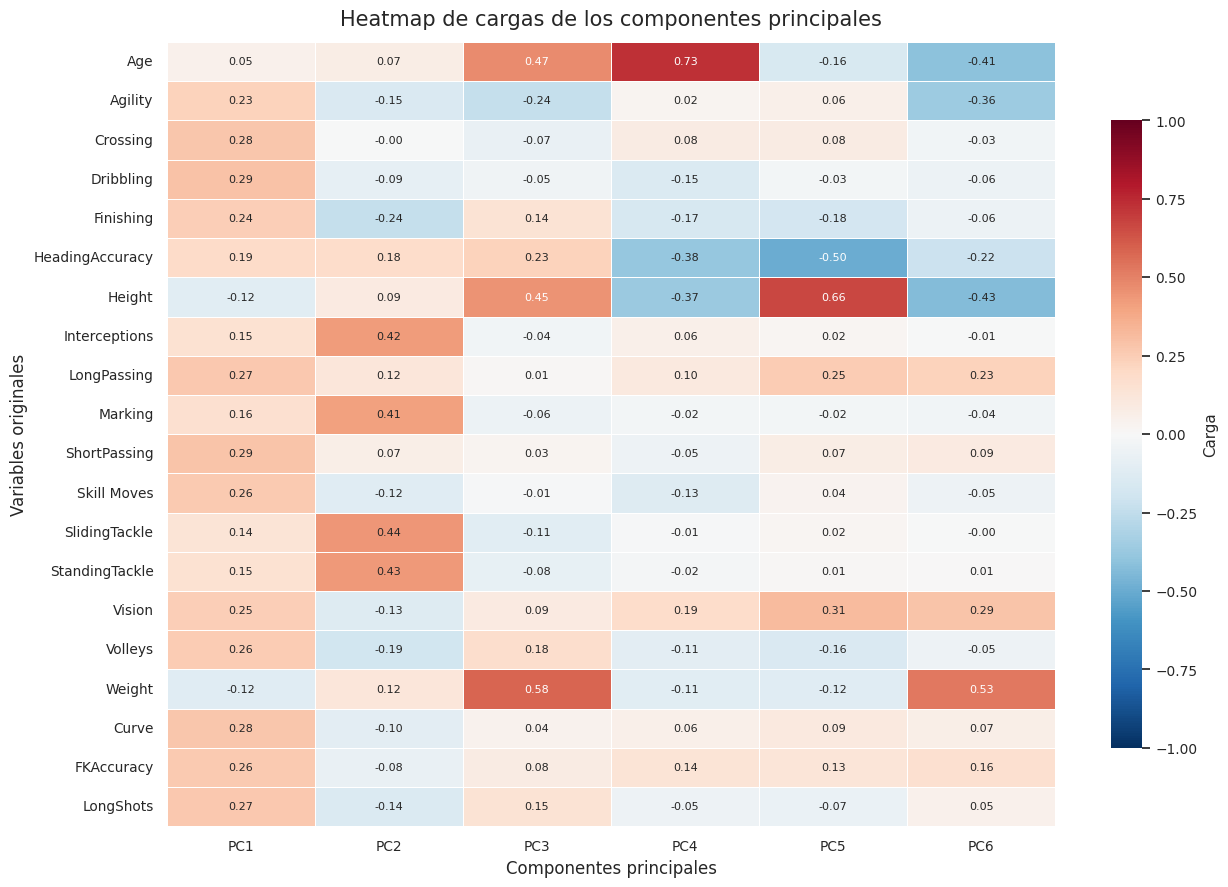

In [18]:
plt.figure(figsize=(13, 9))
sns.set(font_scale=0.9)

ax = sns.heatmap(
    componentes.T,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=.7,
    linecolor="white",
    cbar_kws={"shrink": 0.8, "label": "Carga"},
    annot_kws={"size": 8}
)

ax.set_title("Heatmap de cargas de los componentes principales", fontsize=15, pad=12)
ax.set_xlabel("Componentes principales", fontsize=12)
ax.set_ylabel("Variables originales", fontsize=12)

plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [19]:
proyecciones = pipe.transform(df)

df_pca = proyecciones.iloc[:, :6].copy()
df_pca.columns = ['PC1', 'PC2','PC3', 'PC4','PC5', 'PC6']

display(df_pca.head())

,PC1,PC2,PC3,PC4,PC5,PC6
0,7.156769,-4.011172,1.869303,0.596154,0.677514,0.173958
1,6.203544,-3.374911,3.591025,-0.551365,0.002934,-0.489226
2,6.552405,-3.951648,0.736433,-0.335103,1.236892,-0.350522
3,7.411965,-1.221479,0.020577,1.018007,0.584652,1.333825
4,6.078163,-3.405733,1.152144,0.049416,1.070019,0.260689


In [24]:
df_plot = df.copy().reset_index(drop=True)
df_plot = pd.concat([df_plot, df_pca.reset_index(drop=True)], axis=1)

fig = px.scatter(
    df_plot,
    x='PC1',
    y='PC2',
    size='FKAccuracy',
    hover_data=[
        'Age', 'Agility', 'Crossing', 'Dribbling', 'Finishing',
        'HeadingAccuracy', 'Height', 'Interceptions', 'LongPassing',
        'Marking', 'ShortPassing', 'Skill Moves', 'SlidingTackle',
        'StandingTackle', 'Vision', 'Volleys', 'Weight', 'Curve',
        'FKAccuracy', 'LongShots'
    ],
    title='PCA de jugadores: proyección en PC1 y PC2',
    opacity=0.70
)

fig.add_vline(x=0, line_dash='dash', line_color='black')
fig.add_hline(y=0, line_dash='dash', line_color='black')

fig.update_layout(
    width=1000,
    height=700
)

fig.show()